# Chapter 12.1 — Text Mining and Standard Sentiment Analysis

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Every earlier chapter began with a table. This one begins with sentences: thirty customer reviews of a noodle shop that nobody has tagged. Step by step they are cut into words, counted into a table, and given one label each: positive, negative or neutral.

**In this chapter:** Natural language processing · Text mining · Sentiment analysis · The workflow · Tokens and stop words · The bag of words · A sentiment lexicon · The rules · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Say what NLP and text mining are**, and what makes text unstructured data.
> - **Name the six steps** of sentiment analysis and say what each one produces.
> - **Prepare a text**: cut it into tokens, remove the stop words, and read a bag of words.
> - **Label a sentence** with a lexicon of scored words and the rules for not, but and really.



**Contents**

- **12.1.1 · Natural language processing** — the technology under this chapter
- **12.1.2 · Text mining** — unstructured text into structured data
- **12.1.3 · Sentiment analysis** — positive, negative or neutral
- **12.1.4 · The workflow** — six steps, and the thirty reviews
- **12.1.5 · Tokens and stop words** — steps 2 and 3
- **12.1.6 · The bag of words** — text becomes a table of counts
- **12.1.7 · A sentiment lexicon** — step 4, and the compound score
- **12.1.8 · The rules** — not, really, but
- **12.1.9 · All thirty reviews, labeled** — the end of step 5
- **12.1.10 · Three approaches** — and where Part 12.2 goes
- **12.1.11 · Glossary** — the terms of this part
- **12.1.12 · Homework** — sixteen cafe reviews



> **How to use this notebook.** Each idea is explained first, with a small example worked by hand, and then run in code one step per cell. The text above a code cell says what the cell does and why; the Interpretation under it reads the result. Two tools do the work: CountVectorizer from scikit-learn prepares and counts the text, and the VADER package carries the lexicon and its rules.



#### Setup

The first cell loads pandas, matplotlib, scikit-learn and the VADER sentiment package. Colab does not include VADER, so the cell installs it the first time it runs; after that it only imports.



In [1]:
try:
    import vaderSentiment
except ImportError:              # Colab does not include VADER; install it once
    %pip install -q vaderSentiment

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_colwidth", 80)
print("pandas", pd.__version__, "· ready")

pandas 2.3.3 · ready


## 12.1.1 · Natural language processing

*the technology under this chapter*

> **Definition.** **Natural language processing (NLP)** is the set of methods that let a computer interpret and work with human language: language full of slang, misspellings, sarcasm and words with two meanings.

Four products in daily use are built on it. Each one takes raw language in and hands a structured decision back:

- **Spam filter** — reads every incoming email and decides whether it is unwanted.
- **Voice search** — turns speech into text, then works out what the words ask for.
- **Machine translation** — rewrites a text in another language and keeps its meaning.
- **Chatbot** — reads a typed question, decides what is asked, and writes a reply.

Sentiment analysis, the subject of this chapter, has the same shape: a text goes in, a label comes out.



#### A spam filter

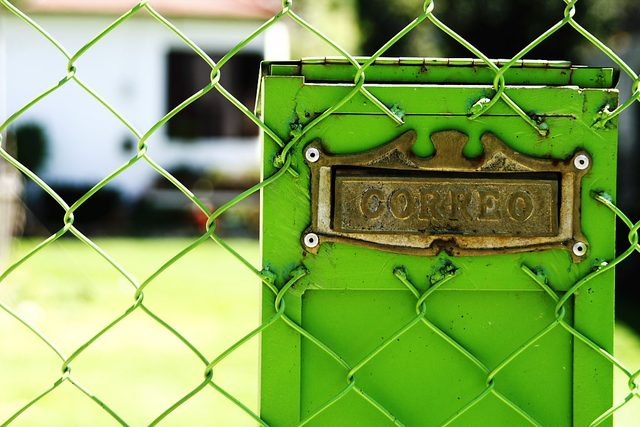

*An inbox: a spam filter reads every message in it before the reader does. — Photo: “eMail” by Esparta, CC BY*



## 12.1.2 · Text mining

*unstructured text into structured data*

Section 12.1.1 named the technology. This section names what it is used for in business analytics.

> **Definition.** **Text mining** takes text that is **unstructured** (sentences with no rows, no columns and no fixed fields) and turns it into **structured data**: a table of counts, scores and labels that the tools of the earlier chapters can analyze.

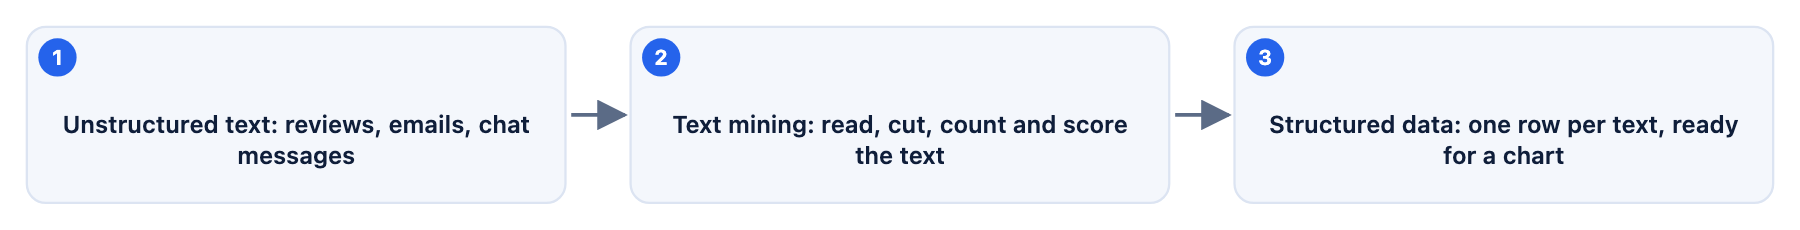

*Text mining turns free-form sentences into a table.*



#### The example of this chapter

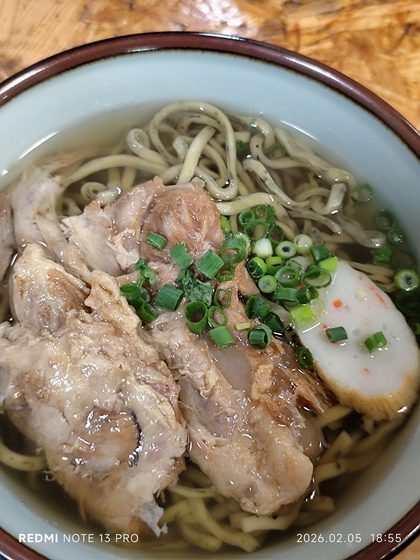

*The kind of shop the thirty reviews are about. — Photo: rib noodle soup bowl by NORTLAUKAU 26088 JP, CC0*

A noodle shop takes orders through an app and delivers. It has thirty customer reviews, each with the customer's 1-to-5 star rating: *The delivery took two hours and the noodles were cold.* *Great value for the price.* *The app crashes every time I open it.* The owner wants to know what customers think and what to fix first. The reviews answer that only once they have been turned into data.



## 12.1.3 · Sentiment analysis

*positive, negative or neutral*

> **Definition.** **Sentiment analysis** reads a text and reports the opinion in it. In its standard form it answers one question with one of three labels: is the opinion **positive**, **negative** or **neutral**?

| Review | Label |
|---|---|
| *The noodles were delicious and the broth was rich.* | positive |
| *Slow service and a dirty table.* | negative |
| *The delivery took two hours and the noodles were cold.* | neutral, for the method of this part |



#### What one label is for

- **A label can be counted.** Once each review has one, the shop can say that 15 of 30 are positive and 13 negative.
- **Tracked over weeks**, the share of negative reviews is a warning light; split by branch or product, it says where to look.
- **The third row above is a complaint**, yet the method of this part calls it neutral. It stays in the table on purpose: Section 12.1.7 shows the reason, which is the main limit of a word-based method.

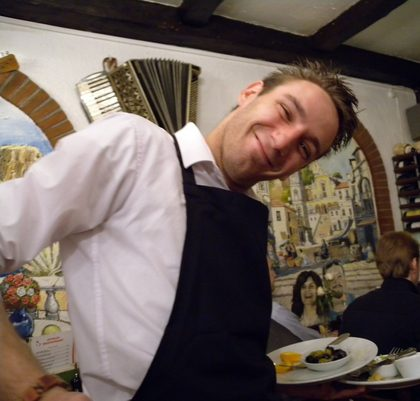

*Service is one of the things the reviews talk about. — Photo: “Cheeeeeese!” by Steve Parker, CC BY*



## 12.1.4 · The workflow

*six steps, and the thirty reviews*

A sentiment analysis runs in six steps, from the raw text to a decision. This part carries out steps 1 to 5 on the thirty reviews, one section per step; step 6, reading the labels as a decision, is the subject of Part 12.2.

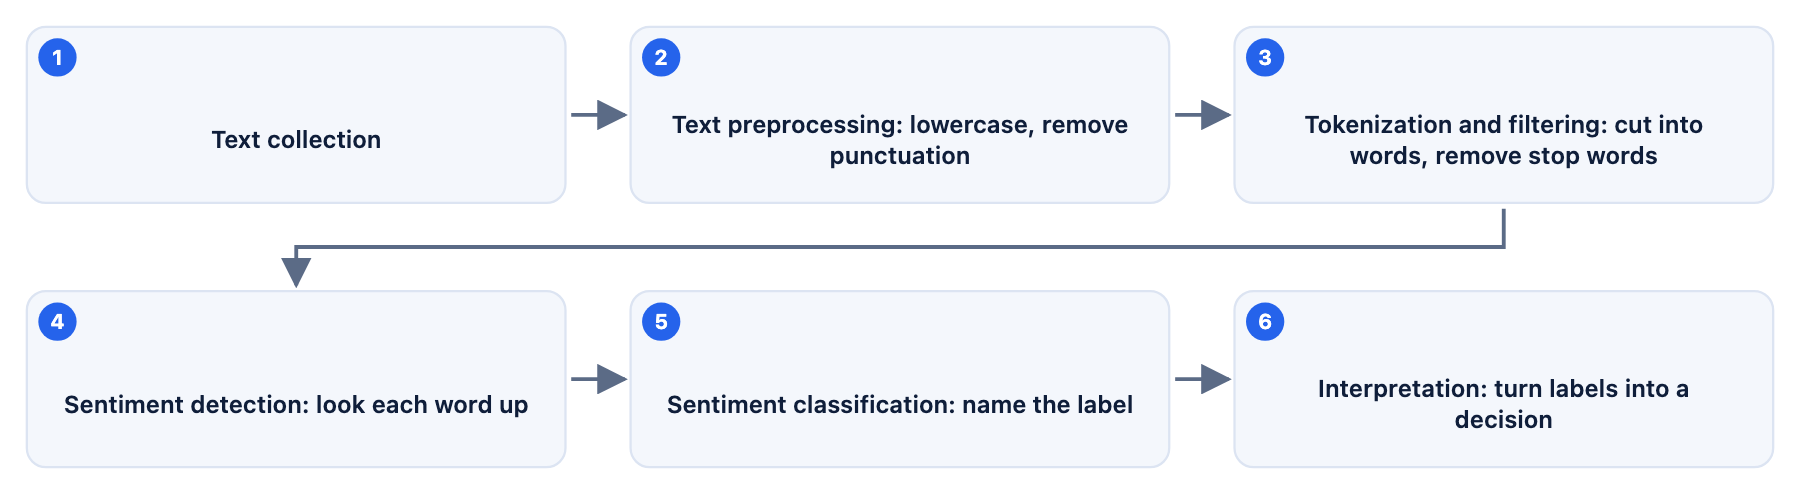

*The six steps of sentiment analysis.*

Steps 4 and 5 can be done two ways. **Lexicon- and rule-based** analysis uses a list of scored words and rules for how words change each other; that is this part. **Machine-learning-based** analysis learns which words signal which label from reviews that already carry one; Part 12.2 gives an overview.



#### Step 1: the thirty reviews

Text collection is the first step. The thirty reviews are typed in as a table with the star rating beside each one, numbered 1 to 30. The stars are kept to one side for now; the `review` column is what the next sections work on.



In [2]:
reviews = pd.DataFrame([
    ["The noodles were delicious and the broth was rich.", 5],
    ["Great value for the price, a big portion for 60 baht.", 5],
    ["Friendly staff and very quick service.", 5],
    ["The delivery was fast and the food arrived hot, perfect.", 5],
    ["The app is easy to use and ordering took one minute.", 4],
    ["Tasty food, fair price, will order again.", 5],
    ["The driver was friendly and arrived early.", 4],
    ["Excellent soup, the best in town.", 5],
    ["Good portions and a fair price.", 4],
    ["The staff were helpful when I changed my order.", 4],
    ["Fast delivery and the packaging kept everything warm.", 5],
    ["Love the new app, the order button is easy to find.", 5],
    ["Fresh vegetables and a wonderful spicy broth.", 5],
    ["A fair price for such a generous bowl.", 4],
    ["The service was quick and the food was great.", 5],
    ["The delivery took two hours and the noodles were cold.", 1],
    ["Terrible service, the staff ignored us.", 1],
    ["Overpriced and disappointing for such a small portion.", 2],
    ["The app crashes every time I open it.", 1],
    ["The driver was rude and the order was wrong.", 1],
    ["The broth was bland and the noodles were a disappointment.", 2],
    ["Slow service and a dirty table.", 2],
    ["The price went up again, not worth it anymore.", 2],
    ["Late delivery and a useless phone line, nobody answered.", 1],
    ["The app is a mess, it logged me out twice during payment.", 2],
    ["Awful food, the meat was not fresh.", 1],
    ["The delivery was late again and the driver was rude.", 1],
    ["Poor value, the portion was tiny for the price.", 2],
    ["Bad packaging, the bag was leaking and the order arrived late.", 1],
    ["The noodles were delicious, but the delivery was a disaster, two hours late.", 2],
], columns=["review", "stars"])
reviews.index = range(1, 31)          # number the reviews 1 to 30
print("shape:", reviews.shape)

shape: (30, 2)


#### The first reviews

`head` shows the first rows of the table, so the text and its stars can be read.



> **Interpretation.** Thirty rows and two columns, and the column that matters holds text. Nothing in it can be summed or averaged yet. Reviews 1 to 15 were rated 4 or 5 stars and 16 to 30 were rated 1 or 2; the code has not been told that.



In [3]:
reviews.head(5)

,review,stars
1,The noodles were delicious and the broth was rich.,5
2,"Great value for the price, a big portion for 60 baht.",5
3,Friendly staff and very quick service.,5
4,"The delivery was fast and the food arrived hot, perfect.",5
5,The app is easy to use and ordering took one minute.,4


## 12.1.5 · Tokens and stop words

*steps 2 and 3*

The reviews are sentences. Before anything can be counted or scored, each one is cut into its words.

> **Definition.** A **token** is one unit of text, usually one word. **Text preprocessing** lowercases the text and removes punctuation and symbols. **Tokenization** cuts it into tokens. **Filtering** removes the tokens that carry no opinion, above all the **stop words** such as *the*, *and* and *was*, which appear in almost every sentence.



#### Worked example: review 16

*The delivery took two hours and the noodles were cold.*

- **Lowercase and remove the period:** *the delivery took two hours and the noodles were cold*.
- **Cut at the spaces:** 10 tokens.
- **Remove the stop words** *the* (twice), *and*, *were* and *two*: 5 tokens remain, *delivery*, *took*, *hours*, *noodles*, *cold*.

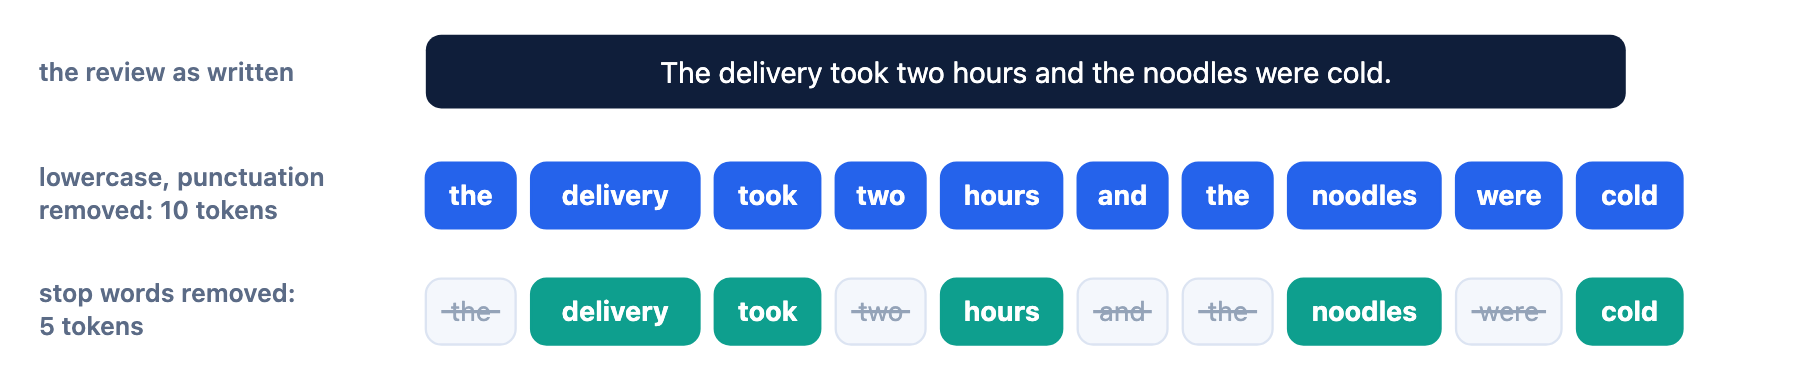

*Review 16 cut into tokens, then filtered: the four stop words are crossed out and the five words that remain say what the review is about.*

> **Why lowercase first.** *Cold*, *cold* and *COLD* are one word to a reader and three to a computer. Lowercasing first makes them one token, so every later count and lookup sees one word.



#### The steps

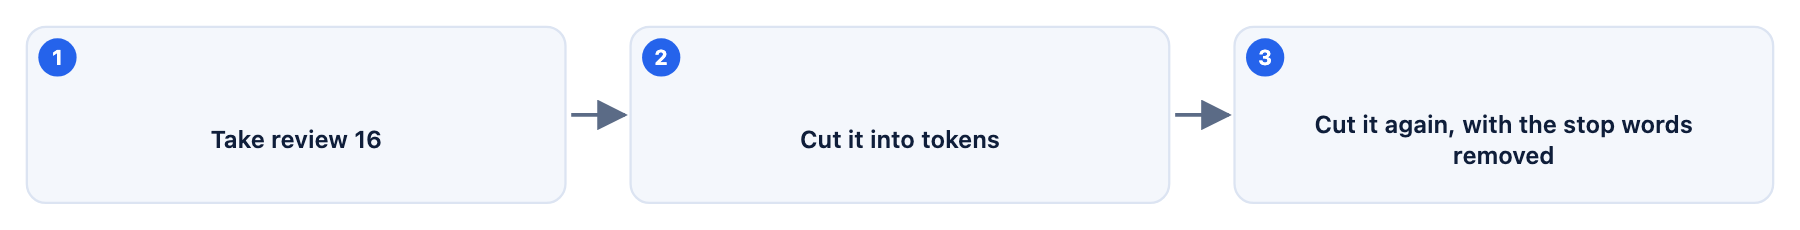

*The code of this section.*



#### The tokens of review 16

A `CountVectorizer` carries an **analyzer**: the function that lowercases a text, drops the punctuation and cuts it into tokens. `build_analyzer()` hands that function over so it can be used on one sentence at a time.



> **Interpretation.** Ten tokens, as in the worked example: all lowercase, the final period gone, one word per token.



In [4]:
text = reviews.loc[16, "review"]
tokenize = CountVectorizer().build_analyzer()        # lowercase, drop punctuation, split into words
print(text)
tokenize(text)

The delivery took two hours and the noodles were cold.


['the',
 'delivery',
 'took',
 'two',
 'hours',
 'and',
 'the',
 'noodles',
 'were',
 'cold']

#### Without the stop words

The same analyzer built with `stop_words="english"` also removes the words on scikit-learn's English stop-word list, about three hundred of them.



> **Interpretation.** Five tokens remain: *delivery*, *took*, *hours*, *noodles* and *cold*, the five of the worked example. The opinion is still there in *cold*, but nothing has yet said whether *cold* is good or bad. That is step 4, in Section 12.1.7.



In [5]:
tokenize_filtered = CountVectorizer(stop_words="english").build_analyzer()
tokenize_filtered(text)

['delivery', 'took', 'hours', 'noodles', 'cold']

## 12.1.6 · The bag of words

*text becomes a table of counts*

Section 12.1.5 cut one review into words. The bag of words does it for every review at once and counts the result, which is the moment text becomes a table.

> **Definition.** The **bag of words** turns text into numbers by counting: one row per text, one column per distinct word in the collection, and in each cell the number of times that word appears in that text.

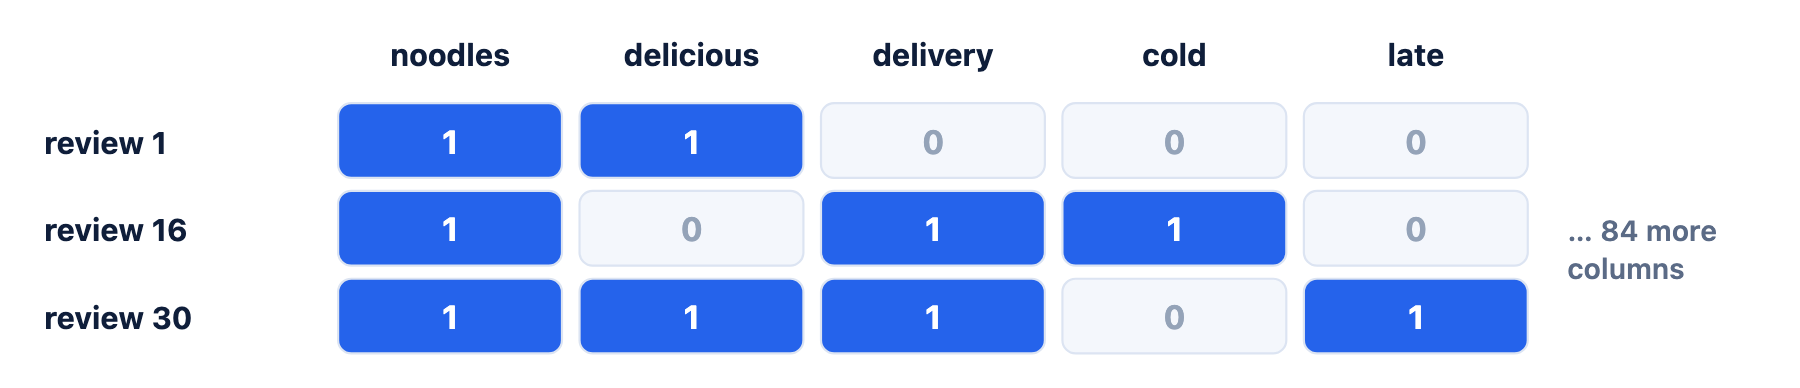

*Three rows of the bag of words, five of its 89 columns. A filled cell means the review used that word; the number is how many times.*



#### What is kept and what is lost

- **Kept:** which words each review used, and how often.
- **Lost:** the order of the words. It is a bag, not a sentence: the table cannot see that review 30's *delicious* comes before a *but*. The rules of Section 12.1.8 put some of that order back.
- **Gained:** every review is now a row of numbers. Summed down a column, the table says which words customers use most; handed to a classifier, the rows are features like the columns of Chapter 10.



#### The steps

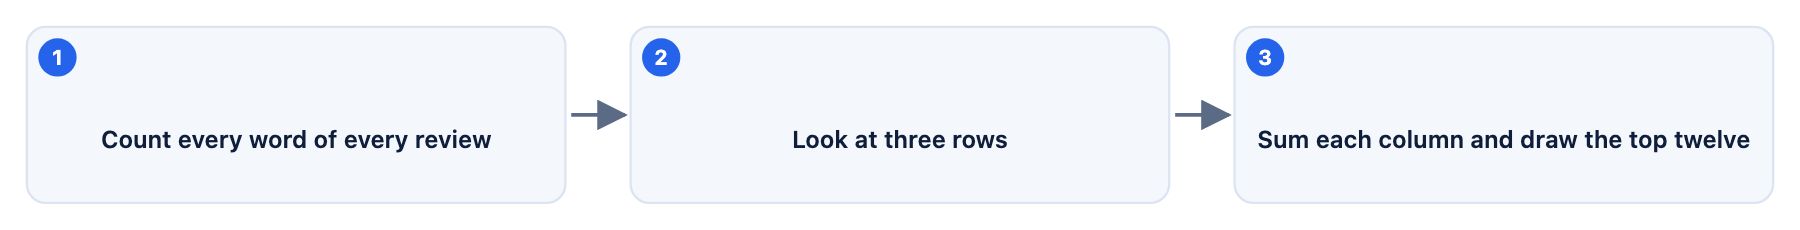

*The code of this section.*



#### The bag of words of the thirty reviews

`fit_transform` runs the analyzer over all thirty reviews, collects every distinct word as a column and counts. The result is stored compactly, so it is turned into a DataFrame with the words as column names.



> **Interpretation.** 30 rows by 89 columns: thirty reviews use 89 distinct words once the stop words are gone. The three rows shown are the three rows of the figure in Section 12.1.6, cell for cell.



In [6]:
vectorizer = CountVectorizer(stop_words="english")
bag = vectorizer.fit_transform(reviews["review"])
counts = pd.DataFrame(bag.toarray(), columns=vectorizer.get_feature_names_out(), index=reviews.index)
print("bag of words:", counts.shape[0], "reviews x", counts.shape[1], "words")
counts.loc[[1, 16, 30], ["noodles", "delicious", "delivery", "cold", "late"]]

bag of words: 30 reviews x 89 words


,noodles,delicious,delivery,cold,late
1,1,1,0,0,0
16,1,0,1,1,0
30,1,1,1,0,1


#### The most frequent words

Summing each column gives the number of times a word appears across all thirty reviews. `sort_values` puts the most frequent first, and the top twelve are drawn.



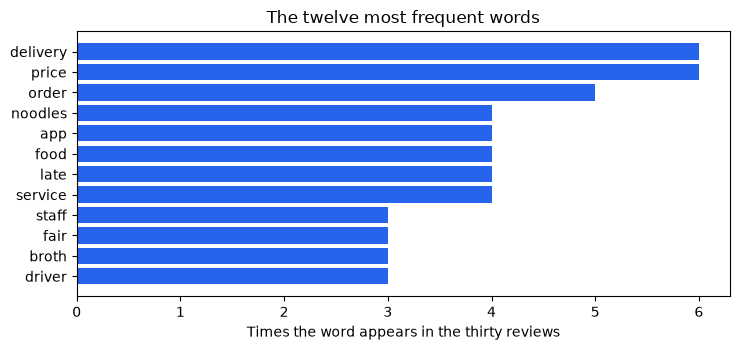

In [7]:
word_totals = counts.sum().sort_values(ascending=False)
top = word_totals.head(12)

plt.figure(figsize=(7.5, 3.6))
plt.barh(top.index[::-1], top.values[::-1], color="#2563EB")
plt.xlabel("Times the word appears in the thirty reviews")
plt.title("The twelve most frequent words")
plt.tight_layout()
plt.show()

#### Reading the chart

> **Interpretation.** The top of the list is what the customers write about:
>
> - **Delivery and price** lead with 6 each, then **order** with 5 and **noodles, app, food, late and service** with 4. These are the parts of the shop the customers write about; Part 12.2 scores them one by one.
> - **Late** appears four times: the times the word appears in the thirty reviews say nothing about good or bad, but every one of the four is in a review rated 1 or 2 stars.



#### Where Section 12.1.6 leaves us

The reviews are now a table of 30 rows and 89 word counts. The counts say what the customers talk about. They do not yet say what the customers feel; that takes a list of words that carry an opinion.



## 12.1.7 · A sentiment lexicon

*step 4, and the compound score*

> **Definition.** A **lexicon** is a list of words, each with a sentiment score given by human raters. The VADER lexicon used here holds about 7,500 English words scored from −4, most negative, to +4, most positive. Looking each token up in it is **sentiment detection**.

| Word | Score | Word | Score |
|---|---|---|---|
| **delicious** | +2.7 | bad | −2.5 |
| **good** | +1.9 | terrible | −2.1 |
| **okay** | +0.9 | rude | −2.0 |
| **cold, late, crashes** | not in the lexicon |  |  |



#### The compound score

**Standard sentiment analysis** adds up the scores of a sentence's words and squeezes the sum into one **compound score** between −1 and +1. Two thresholds turn the compound score into the three labels:

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the word scores}$$

positive if compound ≥ 0.05, negative if compound ≤ −0.05, neutral in between.

> **Worked example.** *The food was good.* has one scored word, *good*, so $x = 1.9$ and $\text{compound} = 1.9/\sqrt{1.9^2 + 15} = 1.9/4.31 = 0.44$. That is at least 0.05, so the sentence is positive.



#### Where the formula comes from

- **The sum can be any size.** Two strong words give 5 or more, a long complaint −10; a raw sum cannot be compared across sentences of different lengths.
- **Dividing by $\sqrt{x^2 + 15}$ keeps the result between −1 and +1**, because the bottom is always a little larger than $|x|$. The sign of $x$ is kept; a sum of 0 stays 0.
- **Large sums flatten out.** A sum of 2 gives 0.46 and a sum of 8 gives 0.90: each extra positive word adds less than the one before. The 15 is the constant VADER's authors chose to set how fast that happens.

> **A lexicon knows only its list.** *Cold*, *late* and *crashes* have no score. For a noodle shop those are among the commonest complaints, so review 16 (*two hours … cold*) and review 19 (*the app crashes*) have a sum of 0 and are called neutral. The lexicon did not misjudge them; it did not see them.



#### The steps

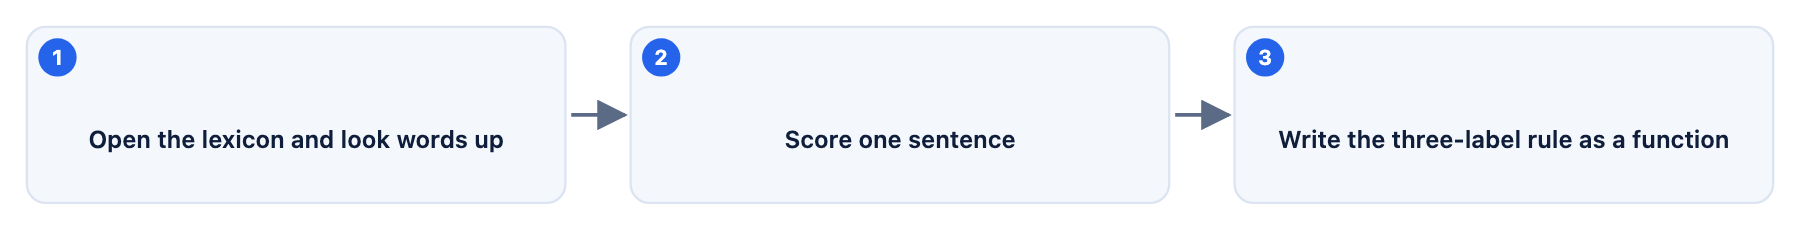

*The code of this section.*



#### The lexicon

The `SentimentIntensityAnalyzer` carries the lexicon as a dictionary, `lexicon`: a word goes in, its score comes out. `.get(word, ...)` returns the second argument for a word the dictionary does not hold.



> **Interpretation.** The scores of the table in Section 12.1.7, and the three complaint words missing from a list of 7,506.



In [8]:
analyzer = SentimentIntensityAnalyzer()
lexicon = analyzer.lexicon
print("words in the lexicon:", len(lexicon))
for word in ["delicious", "good", "okay", "bad", "terrible", "rude", "cold", "late", "crashes"]:
    print(f"{word:10s} {lexicon.get(word, 'not in the lexicon')}")

words in the lexicon: 7506
delicious  2.7
good       1.9
okay       0.9
bad        -2.5
terrible   -2.1
rude       -2.0
cold       not in the lexicon
late       not in the lexicon
crashes    not in the lexicon


#### One sentence, scored

`polarity_scores` looks every word up, applies the rules of Section 12.1.8, and returns four numbers. `compound` is the score of the formula; `neg`, `neu` and `pos` are the shares of the sentence that were negative, neutral and positive.

$$\text{compound} = \frac{x}{\sqrt{x^2 + 15}}, \qquad x = \text{the sum of the word scores}$$

positive if compound ≥ 0.05, negative if compound ≤ −0.05, neutral in between.



> **Interpretation.** compound 0.4404, the 0.44 of the worked example. *Good* is the only word with an opinion, so pos is about half and neg is zero.



In [9]:
analyzer.polarity_scores("The food was good.")

{'neg': 0.0, 'neu': 0.508, 'pos': 0.492, 'compound': 0.4404}

#### The three-label rule as a function

`sentiment_of` is the whole classifier of standard sentiment analysis: one call to `polarity_scores`, two thresholds, three labels. It is used on every sentence from here on.



In [10]:
def sentiment_of(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

sentiment_of("The food was good.")

'positive'

## 12.1.8 · The rules

*not, really, but*

A lexicon alone gives *not good* the same score as *good*, since both contain *good*. **Rule-based** sentiment analysis adds rules for how words change each other. VADER applies three kinds, each with a fixed number:

| Rule | What it does | Worked on good (+1.9) | Compound |
|---|---|---|---|
| **Negation** | *not* or *never* before a word multiplies its score by −0.74 | *not good*: 1.9 × (−0.74) = −1.41 | −0.34 |
| **Intensifier** | *really* or *very* adds 0.293 to the size of the next word's score; each *!* adds 0.292 | *really good!*: 1.9 + 0.293 + 0.292 = 2.49 | +0.54 |
| **Contrast** | *but*: words before it count half, words after it count one and a half times | *good, but … really bad*: 1.9 × 0.5 + (−2.5 − 0.293) × 1.5 = −3.24 | −0.64 |

Each compound in the last column is the formula of Section 12.1.7 applied to the sum: $-1.41/\sqrt{1.41^2 + 15} = -0.34$, and so on.

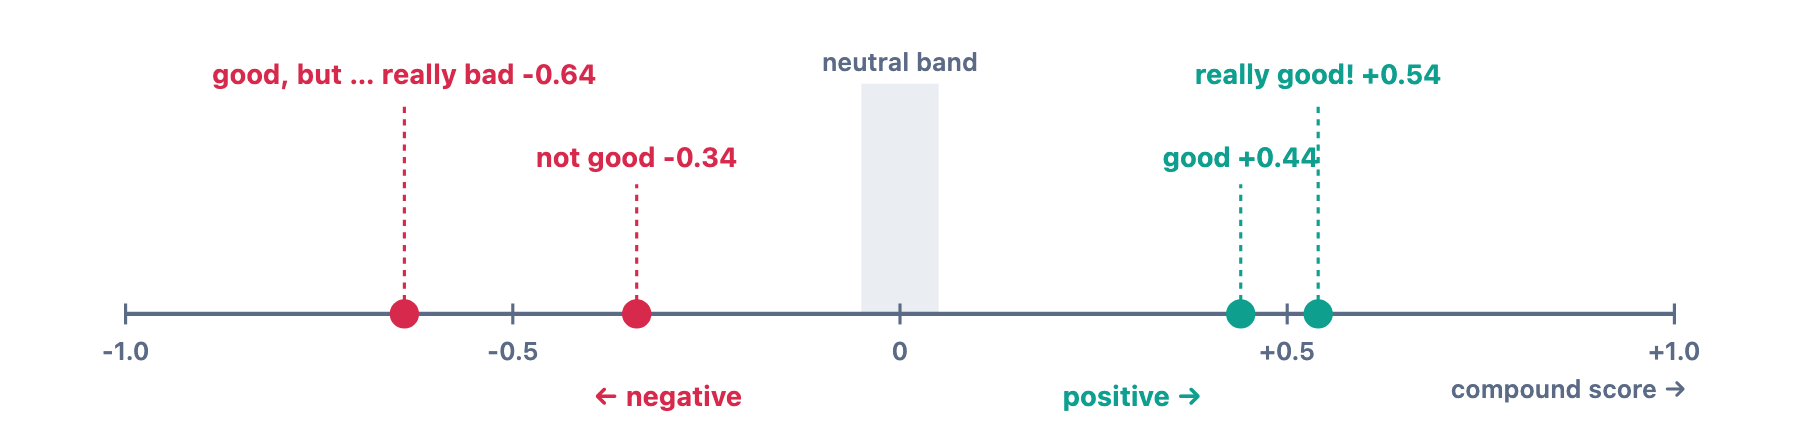

*The four sentences on the compound score's scale. The shaded band between −0.05 and +0.05 is labeled neutral.*



#### The four sentences

The four sentences of the table are scored by the tool, with the label beside each compound score, so each row can be checked against the hand calculation.

$$\textit{not}: \times(-0.74) \qquad \textit{really}: +0.293 \qquad \textit{!}: +0.292 \qquad \textit{but}: \text{before} \times 0.5,\ \text{after} \times 1.5$$



> **Interpretation.** The table's four numbers, from the tool:
>
> - ***not good*** −0.34: the negation rule flipped the sign of *good*.
> - ***really good!*** +0.54: the intensifier and the exclamation mark each pushed the score further from 0.
> - ***good, but … really bad*** −0.64: the second half counts more, so the sentence is negative although it contains a positive word.



In [11]:
sentences = ["The food was good.",
             "The food was not good.",
             "The food was really good!",
             "The hotel was good, but the food was really bad."]
pd.DataFrame({"sentence": sentences,
              "compound": [analyzer.polarity_scores(s)["compound"] for s in sentences],
              "sentiment": [sentiment_of(s) for s in sentences]})

,sentence,compound,sentiment
0,The food was good.,0.4404,positive
1,The food was not good.,-0.3412,negative
2,The food was really good!,0.5400,positive
3,"The hotel was good, but the food was really bad.",-0.6416,negative


#### Try it: a contrast word without a rule

> **Try it.** Add *Although the food was good, the service was terrible.* to the list and run the cell again.
>
> *Answer.* It scores only −0.05. VADER has a rule for *but* and none for *although*, so the two halves nearly cancel. Every rule list has gaps.



## 12.1.9 · All thirty reviews, labeled

*the end of step 5*

The lexicon, the rules and the three-label function are in place. Applied to all thirty reviews, they finish step 5: one compound score and one label per review. The star ratings, kept aside since Section 12.1.4, then say how often the label is right.

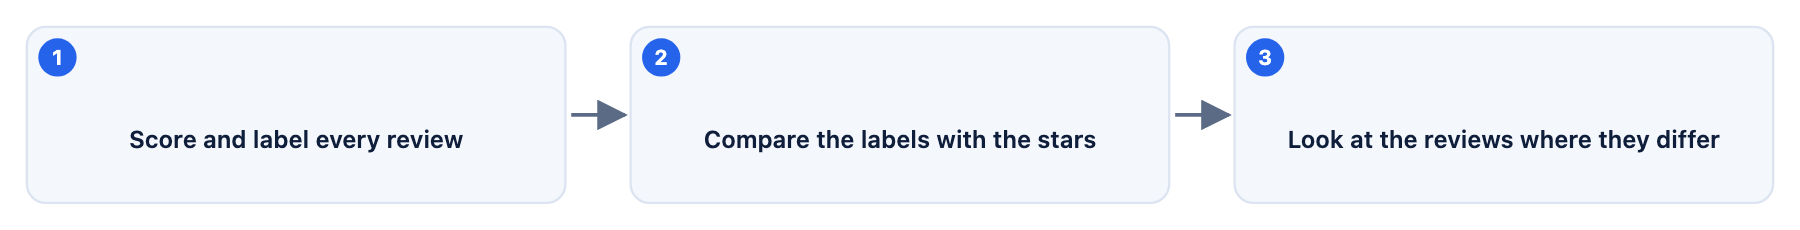

*The code of this section.*



#### A score and a label for every review

Two new columns: the compound score of each review, and its label from sentiment_of. `value_counts` counts the labels.



> **Interpretation.** 15 positive, 13 negative, 2 neutral.



In [12]:
reviews["compound"] = [analyzer.polarity_scores(t)["compound"] for t in reviews["review"]]
reviews["sentiment"] = reviews["review"].apply(sentiment_of)
reviews["sentiment"].value_counts()

sentiment
positive    15
negative    13
neutral      2
Name: count, dtype: int64

#### The labels against the stars

A review rated 4 or 5 stars is taken as positive and one rated 1 or 2 as negative. `pd.crosstab` counts how the two agree.



> **Interpretation.** 28 of 30. All 15 reviews rated 4 or 5 stars are positive; of the 15 rated 1 or 2, 13 are negative and 2 are neutral. The lexicon never called a complaint positive.



In [13]:
star_label = reviews["stars"].map(lambda s: "positive" if s >= 4 else "negative")
print("the label agrees with the stars on", (reviews["sentiment"] == star_label).sum(), "of 30 reviews")
pd.crosstab(star_label, reviews["sentiment"], rownames=["stars"], colnames=["lexicon"])

the label agrees with the stars on 28 of 30 reviews


lexicon,negative,neutral,positive
stars,,,
negative,13,2,0
positive,0,0,15


#### The two reviews it missed

The rows labeled neutral are pulled out, with review 30 beside them because it mixes praise and a complaint.



> **Interpretation.** Reading the three rows:
>
> - **Reviews 16 and 19** score exactly 0. Their complaint words, *cold* and *crashes*, are not in the lexicon, so the sum of the word scores is 0.
> - **Review 30** is negative at −0.65: after *but*, *disaster* (−3.1) outweighs *delicious* (+2.7).



In [14]:
reviews.loc[[16, 19, 30], ["review", "stars", "compound", "sentiment"]]

,review,stars,compound,sentiment
16,The delivery took two hours and the noodles were cold.,1,0.0000,neutral
19,The app crashes every time I open it.,1,0.0000,neutral
30,"The noodles were delicious, but the delivery was a disaster, two hours late.",2,-0.6486,negative


#### Try it: other reviews

> **Try it.** Run `reviews.sort_values("compound")` in a new cell to see all thirty from most negative to most positive. Where does review 3 (*Friendly staff and very quick service*) sit, and why is it not higher?
>
> *Answer.* At +0.49. *Friendly* is scored and *very* is an intensifier, but *quick* is not in the lexicon.



## 12.1.10 · Three approaches

*and where Part 12.2 goes*

This part used one of three ways to do steps 4 and 5:

| Approach | How it works | Strength | Limit |
|---|---|---|---|
| **Lexicon- and rule-based** | a list of scored words and hand-written rules | needs no training data; every label can be explained by a word and a rule | blind to any word not on its list |
| **Machine-learning-based** | a classifier learns which words go with which label from reviews that already carry one (Chapter 10, with the bag of words as features) | learns words no lexicon has | knows only the words its training reviews contain |
| **Hybrid** | a learned classifier with a lexicon and rules on top | handles rare words, negation and contrast | the most work to build; what most commercial systems use |



#### Where Part 12.1 leaves us

- **Text becomes a table by counting**: lowercase, cut into tokens, drop the stop words, count. Thirty reviews became 30 rows by 89 words.
- **A lexicon plus rules reads opinion**: word scores give a compound score, the rules for *not*, *really* and *but* correct it, and two thresholds give the label.
- **A lexicon knows only its list**: two plain complaints were called neutral.

> **Next: Part 12.2.** Every review now has one label. Part 12.2 asks what that label hides: how strong the opinion is, which emotion it carries, and which part of the shop it is about, and it turns the answers into what the owner should fix first.



## 12.1.11 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Natural language processing** | Methods that let a computer interpret and work with human language. |
| **Text mining** | Turning unstructured text into structured data that can be analyzed. |
| **Sentiment analysis** | Reading the opinion in a text; in its standard form, positive, negative or neutral. |
| **Token** | One unit of text, usually one word. |
| **Tokenization** | Cutting a text into tokens. |
| **Stop words** | Common words such as the, and, was that carry no opinion and are removed. |
| **Bag of words** | A table with one row per text, one column per word, and a count in each cell. |
| **Lexicon** | A list of words, each with a sentiment score. |
| **Compound score** | One number between −1 and +1 summing up the scores of a sentence's words. |
| **Negation, intensifier, contrast** | The three kinds of rule: not flips a score, really strengthens it, but gives the second half more weight. |



## 12.1.12 · Homework

*sixteen cafe reviews*

The exercises repeat steps 2 to 5 on a new set of reviews, in the order this part taught them. Each exercise has a code cell for your work and a text cell for your answer.

**Student information**: double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework data: sixteen cafe reviews

*run this cell, but do not modify it*

Run this cell once and do not edit it. It defines `cafe`, sixteen reviews of a cafe with their star ratings, and loads the tools again so the homework works even if the cells above were not run.



In [15]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

cafe = pd.DataFrame([
    ["The coffee was excellent and the croissant was fresh.", 5],
    ["Friendly barista and a cozy place to study.", 5],
    ["Great latte for a fair price.", 4],
    ["The wifi is fast and the seats are comfortable.", 4],
    ["Lovely cake, I will come back tomorrow.", 5],
    ["The staff remembered my order, very kind.", 5],
    ["Good coffee, but the seats are hard.", 4],
    ["A quiet corner and the best espresso in the city.", 5],
    ["The coffee was lukewarm and the cup was chipped.", 1],
    ["Rude staff and a dirty table.", 1],
    ["Too expensive and disappointing for such a small cup.", 2],
    ["The wifi keeps dropping, very frustrating.", 2],
    ["The cake was stale and the coffee was not good.", 1],
    ["We waited twenty minutes, terrible service.", 2],
    ["The price is fair, but the barista was unfriendly.", 2],
    ["No seats at all and the music is too loud.", 1],
], columns=["review", "stars"])
cafe.index = range(1, 17)
analyzer = SentimentIntensityAnalyzer()
print("cafe reviews:", len(cafe))

cafe reviews: 16


#### Exercise 1 — Tokens and stop words

Cut review 9 into tokens, first without and then with the English stop words removed. How many tokens does each version have, and which words did filtering remove?

*Hint:* Section 12.1.5, `CountVectorizer().build_analyzer()`.



In [16]:
# YOUR CODE HERE (Exercise 1)

#### Your answer: Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — The bag of words

Build the bag of words of all sixteen reviews with the stop words removed. How many columns does it have? Which five words are the most frequent, and what do they say the customers write about?

*Hint:* Section 12.1.6, `fit_transform` and `.sum().sort_values(ascending=False)`.



In [17]:
# YOUR CODE HERE (Exercise 2)

#### Your answer: Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The lexicon

Look up every token of review 9 (without stop words) in the lexicon, and score the review with `polarity_scores`. Which label does it get? Explain the result using the words that are and are not in the lexicon.

*Hint:* Section 12.1.7, `analyzer.lexicon.get(word, 'not in the lexicon')`.



In [18]:
# YOUR CODE HERE (Exercise 3)

#### Your answer: Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — All sixteen, labeled

Write the three-label function of Section 12.1.7, label all sixteen reviews, and count the labels. Taking 4 or 5 stars as positive and 1 or 2 as negative, on how many reviews does the label agree with the stars? Name any review where it does not and say why.

*Hint:* Section 12.1.9, `pd.crosstab`.



In [19]:
# YOUR CODE HERE (Exercise 4)

#### Your answer: Exercise 4

*Double-click this cell and type your answer here.*



#### Bonus: the rules on review 7 and review 15

Reviews 7 and 15 both contain *but*. Score each whole review, then score the part before and the part after *but* separately. Use the contrast rule of Section 12.1.8 to explain why each whole review gets the label it does.



In [20]:
# YOUR CODE HERE (Bonus)

#### Your answer: the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 4 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime > Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

